# Vegetation Diagnostic Notebook

Purpose:
- Diagnose why vegetation IoU on the public leaderboard is lower than the local validation estimate.
- Focus on `alphaearth_tessera_iou_fusion_C_ch16_h96d2`.
- Compare raw predictions vs the rescaled submission variant.
- Visualize which patch types produce weak vegetation IoU.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from IPython.display import display

REPO = Path.cwd().resolve()
if not (REPO / "core").exists():
    REPO = REPO.parent.resolve()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from core.dataset import normalize_core_id
from core.metrics import LABEL_THRESHOLD, binary_iou, build_label_map, load_val_ids
from tools.calibrate_presence_outputs import calibrate_array

EXP_NAME = "alphaearth_tessera_iou_fusion_C_ch16_h96d2"
PRED_DIR = REPO / "runs" / EXP_NAME / "predictions"
LABELS_DIR = REPO.parent / "data" / "train" / "labels"
SPLIT_FILE = REPO / "splits" / "split.json"
THRESHOLDS = (0.72, 0.54, 0.92)
SCALES = (1.0, 1.0, 1.0)
EPS = 1e-6

print("repo:", REPO)
print("predictions:", PRED_DIR)
print("labels:", LABELS_DIR)
print("split:", SPLIT_FILE)
print("thresholds:", THRESHOLDS)


repo: /u/dingqi2/workspace/esa/emb2heights-backbone
predictions: /u/dingqi2/workspace/esa/emb2heights-backbone/runs/alphaearth_tessera_iou_fusion_C_ch16_h96d2/predictions
labels: /u/dingqi2/workspace/esa/data/train/labels
split: /u/dingqi2/workspace/esa/emb2heights-backbone/splits/split.json
thresholds: (0.72, 0.54, 0.92)


In [2]:
val_ids = load_val_ids(str(SPLIT_FILE))
label_map = build_label_map(str(LABELS_DIR))
pred_files = sorted(PRED_DIR.glob("*.npy"))

rows = []
arrays = {}

for pf in pred_files:
    core_id = normalize_core_id(str(pf))
    if core_id not in val_ids or core_id not in label_map:
        continue

    pred_raw = np.load(pf).astype(np.float32)
    pred_cal = calibrate_array(pred_raw, THRESHOLDS, SCALES, EPS)

    with rasterio.open(label_map[core_id]) as src:
        label = src.read().astype(np.float32)

    h = min(pred_raw.shape[1], label.shape[1])
    w = min(pred_raw.shape[2], label.shape[2])
    pred_raw = pred_raw[:, :h, :w]
    pred_cal = pred_cal[:, :h, :w]
    label = label[:, :h, :w]

    label_veg_mask = label[1] > LABEL_THRESHOLD
    pred_raw_veg_mask = pred_raw[1] > 0.5
    pred_cal_veg_mask = pred_cal[1] > 0.5

    global_nodata = np.all(label == 0, axis=0)
    height_hole = (label[3] == 0) & ((label[0] > 0) | (label[1] > 0) | (label[2] > 0))

    rows.append({
        "core_id": core_id,
        "region": core_id.split("_")[-1],
        "raw_veg_iou": binary_iou(pred_raw_veg_mask, label_veg_mask),
        "cal_veg_iou": binary_iou(pred_cal_veg_mask, label_veg_mask),
        "delta_veg_iou": binary_iou(pred_cal_veg_mask, label_veg_mask) - binary_iou(pred_raw_veg_mask, label_veg_mask),
        "label_veg_pos_rate": float(label_veg_mask.mean()),
        "label_veg_frac_mean": float(label[1].mean()),
        "pred_raw_veg_pos_rate": float(pred_raw_veg_mask.mean()),
        "pred_cal_veg_pos_rate": float(pred_cal_veg_mask.mean()),
        "nodata_frac": float(global_nodata.mean()),
        "height_hole_frac": float(height_hole.mean()),
        "label_build_pos_rate": float((label[0] > LABEL_THRESHOLD).mean()),
        "label_water_pos_rate": float((label[2] > LABEL_THRESHOLD).mean()),
    })

    arrays[core_id] = {
        "label_veg_frac": label[1],
        "label_veg_mask": label_veg_mask.astype(np.float32),
        "pred_raw_veg_score": pred_raw[1],
        "pred_raw_veg_mask": pred_raw_veg_mask.astype(np.float32),
        "pred_cal_veg_score": pred_cal[1],
        "pred_cal_veg_mask": pred_cal_veg_mask.astype(np.float32),
    }

print(f"matched validation samples: {len(rows)}")


matched validation samples: 405


In [3]:
def col(name):
    return np.array([row[name] for row in rows], dtype=np.float64)

print("raw veg IoU mean:      ", round(col("raw_veg_iou").mean(), 4))
print("rescaled veg IoU mean: ", round(col("cal_veg_iou").mean(), 4))
print("delta mean:            ", round(col("delta_veg_iou").mean(), 6))
print("delta min/max:         ", round(col("delta_veg_iou").min(), 6), round(col("delta_veg_iou").max(), 6))
print()
print("label veg pos rate mean:", round(col("label_veg_pos_rate").mean(), 4))
print("raw pred veg pos mean: ", round(col("pred_raw_veg_pos_rate").mean(), 4))
print("cal pred veg pos mean: ", round(col("pred_cal_veg_pos_rate").mean(), 4))
print("nodata frac mean:      ", round(col("nodata_frac").mean(), 4))
print("height hole frac mean: ", round(col("height_hole_frac").mean(), 4))


raw veg IoU mean:       0.7529
rescaled veg IoU mean:  0.7533
delta mean:             0.000451
delta min/max:          -0.020862 0.05218

label veg pos rate mean: 0.4622
raw pred veg pos mean:  0.4773
cal pred veg pos mean:  0.4697
nodata frac mean:       0.3024
height hole frac mean:  0.0188


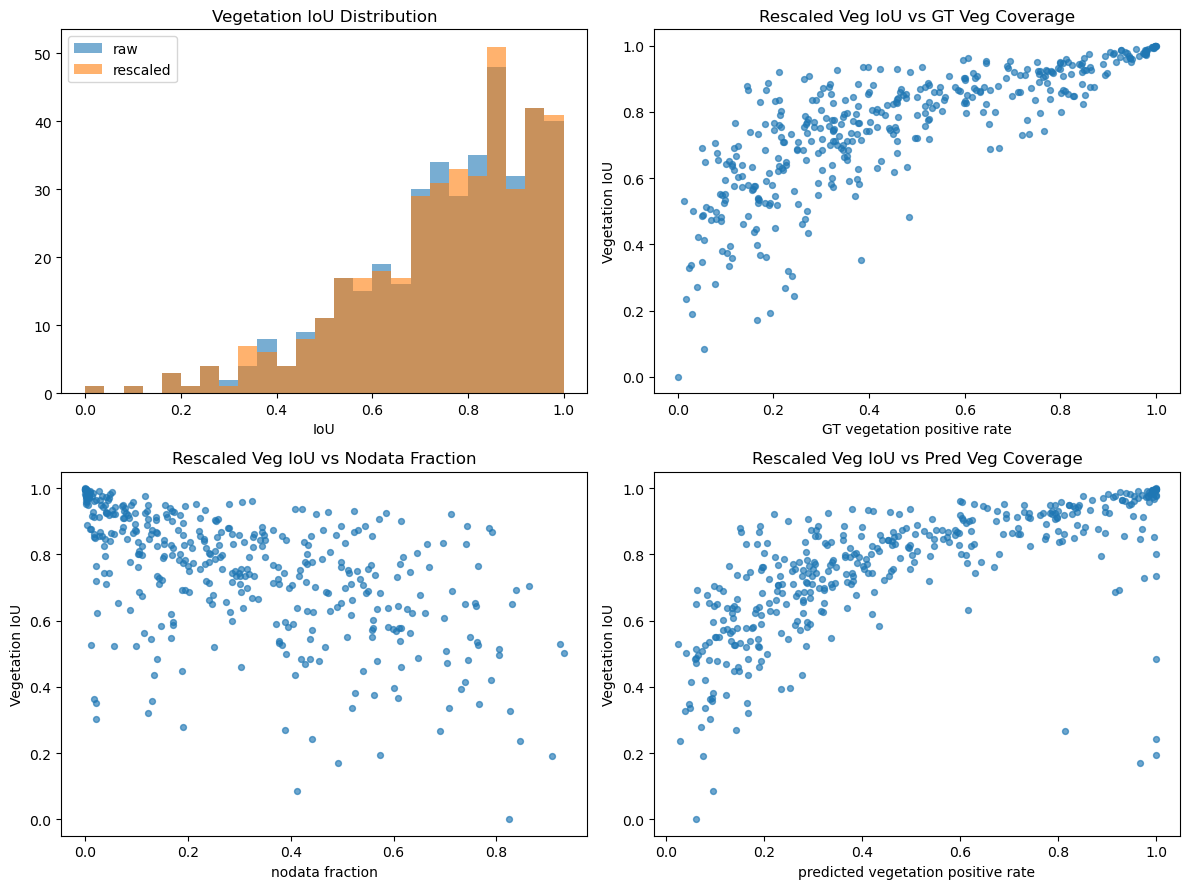

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(col("raw_veg_iou"), bins=25, alpha=0.6, label="raw")
axes[0, 0].hist(col("cal_veg_iou"), bins=25, alpha=0.6, label="rescaled")
axes[0, 0].set_title("Vegetation IoU Distribution")
axes[0, 0].set_xlabel("IoU")
axes[0, 0].legend()

axes[0, 1].scatter(col("label_veg_pos_rate"), col("cal_veg_iou"), s=18, alpha=0.65)
axes[0, 1].set_title("Rescaled Veg IoU vs GT Veg Coverage")
axes[0, 1].set_xlabel("GT vegetation positive rate")
axes[0, 1].set_ylabel("Vegetation IoU")

axes[1, 0].scatter(col("nodata_frac"), col("cal_veg_iou"), s=18, alpha=0.65)
axes[1, 0].set_title("Rescaled Veg IoU vs Nodata Fraction")
axes[1, 0].set_xlabel("nodata fraction")
axes[1, 0].set_ylabel("Vegetation IoU")

axes[1, 1].scatter(col("pred_cal_veg_pos_rate"), col("cal_veg_iou"), s=18, alpha=0.65)
axes[1, 1].set_title("Rescaled Veg IoU vs Pred Veg Coverage")
axes[1, 1].set_xlabel("predicted vegetation positive rate")
axes[1, 1].set_ylabel("Vegetation IoU")

plt.tight_layout()
plt.show()


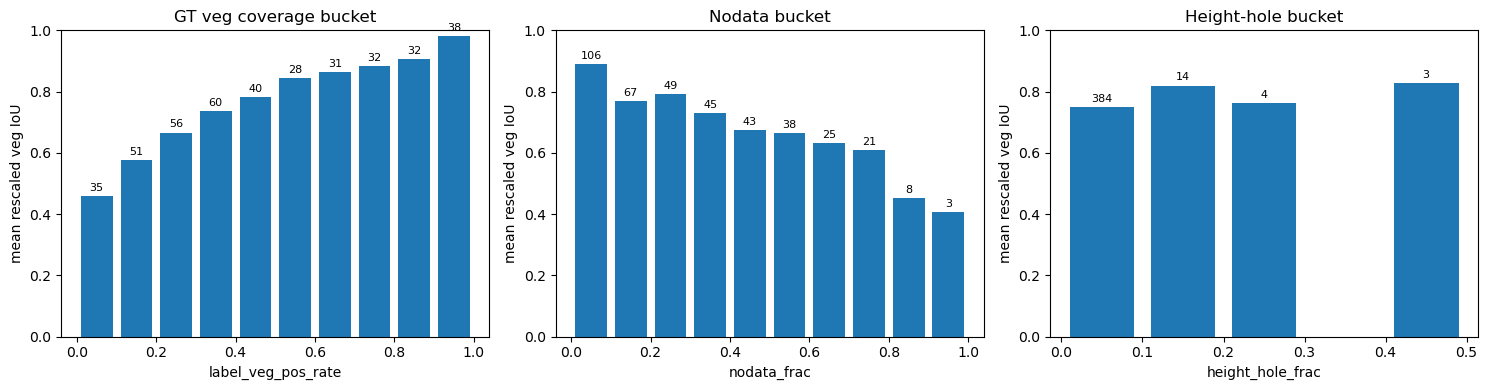

In [5]:
def bucket_mean(x, y, bins):
    idx = np.digitize(x, bins) - 1
    centers = []
    means = []
    counts = []
    for i in range(len(bins) - 1):
        mask = idx == i
        centers.append((bins[i] + bins[i + 1]) / 2)
        means.append(float(np.mean(y[mask])) if mask.any() else np.nan)
        counts.append(int(mask.sum()))
    return np.array(centers), np.array(means), np.array(counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

bins = np.linspace(0, 1, 11)
for ax, xname, title in [
    (axes[0], "label_veg_pos_rate", "GT veg coverage bucket"),
    (axes[1], "nodata_frac", "Nodata bucket"),
    (axes[2], "height_hole_frac", "Height-hole bucket"),
]:
    centers, means, counts = bucket_mean(col(xname), col("cal_veg_iou"), bins)
    ax.bar(centers, means, width=0.08)
    for cx, my, ct in zip(centers, means, counts):
        if not np.isnan(my):
            ax.text(cx, my + 0.01, str(ct), ha="center", va="bottom", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xname)
    ax.set_ylabel("mean rescaled veg IoU")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


In [6]:
regions = sorted({row["region"] for row in rows})
region_means = []
for region in regions:
    vals = [row["cal_veg_iou"] for row in rows if row["region"] == region]
    region_means.append((region, float(np.mean(vals)), len(vals)))

region_means = sorted(region_means, key=lambda x: x[1])
for region, mean_iou, count in region_means:
    print(f"{region:>3}  mean_iou={mean_iou:.4f}  n={count}")


 PH  mean_iou=0.2436  n=1
 OE  mean_iou=0.2679  n=1
 RL  mean_iou=0.2703  n=1
 NQ  mean_iou=0.3203  n=1
 GI  mean_iou=0.3667  n=1
 DH  mean_iou=0.4541  n=2
 ON  mean_iou=0.4692  n=1
 LN  mean_iou=0.4739  n=2
 JB  mean_iou=0.4758  n=2
 LM  mean_iou=0.4771  n=3
 OK  mean_iou=0.4841  n=3
 QM  mean_iou=0.4849  n=2
 JI  mean_iou=0.4864  n=5
 GG  mean_iou=0.5120  n=2
 KA  mean_iou=0.5142  n=7
 KI  mean_iou=0.5264  n=1
 IP  mean_iou=0.5471  n=3
 EG  mean_iou=0.5639  n=2
 LB  mean_iou=0.5710  n=3
 JJ  mean_iou=0.5773  n=3
 FG  mean_iou=0.5780  n=5
 EF  mean_iou=0.5787  n=2
 NK  mean_iou=0.5906  n=1
 SE  mean_iou=0.6155  n=6
 GJ  mean_iou=0.6181  n=2
 HG  mean_iou=0.6186  n=6
 HF  mean_iou=0.6254  n=4
 FD  mean_iou=0.6260  n=4
 GD  mean_iou=0.6272  n=2
 KO  mean_iou=0.6293  n=1
 IQ  mean_iou=0.6301  n=2
 KE  mean_iou=0.6301  n=13
 LK  mean_iou=0.6314  n=6
 OP  mean_iou=0.6324  n=2
 GH  mean_iou=0.6473  n=5
 IG  mean_iou=0.6552  n=1
 JQ  mean_iou=0.6564  n=2
 MJ  mean_iou=0.6718  n=4
 IF  mean_i

In [7]:
rows_sorted = sorted(rows, key=lambda row: row["cal_veg_iou"])
worst_ids = [row["core_id"] for row in rows_sorted[:6]]
best_ids = [row["core_id"] for row in rows_sorted[-6:]][::-1]

print("worst ids:", worst_ids)
print("best ids: ", best_ids)


worst ids: ['1061_QM', '0618_LN', '0832_OK', '1666_JI', '1540_GG', '0196_IF']
best ids:  ['0544_KS', '1132_RE', '1037_QG', '1290_VS', '0909_PI', '1289_VS']


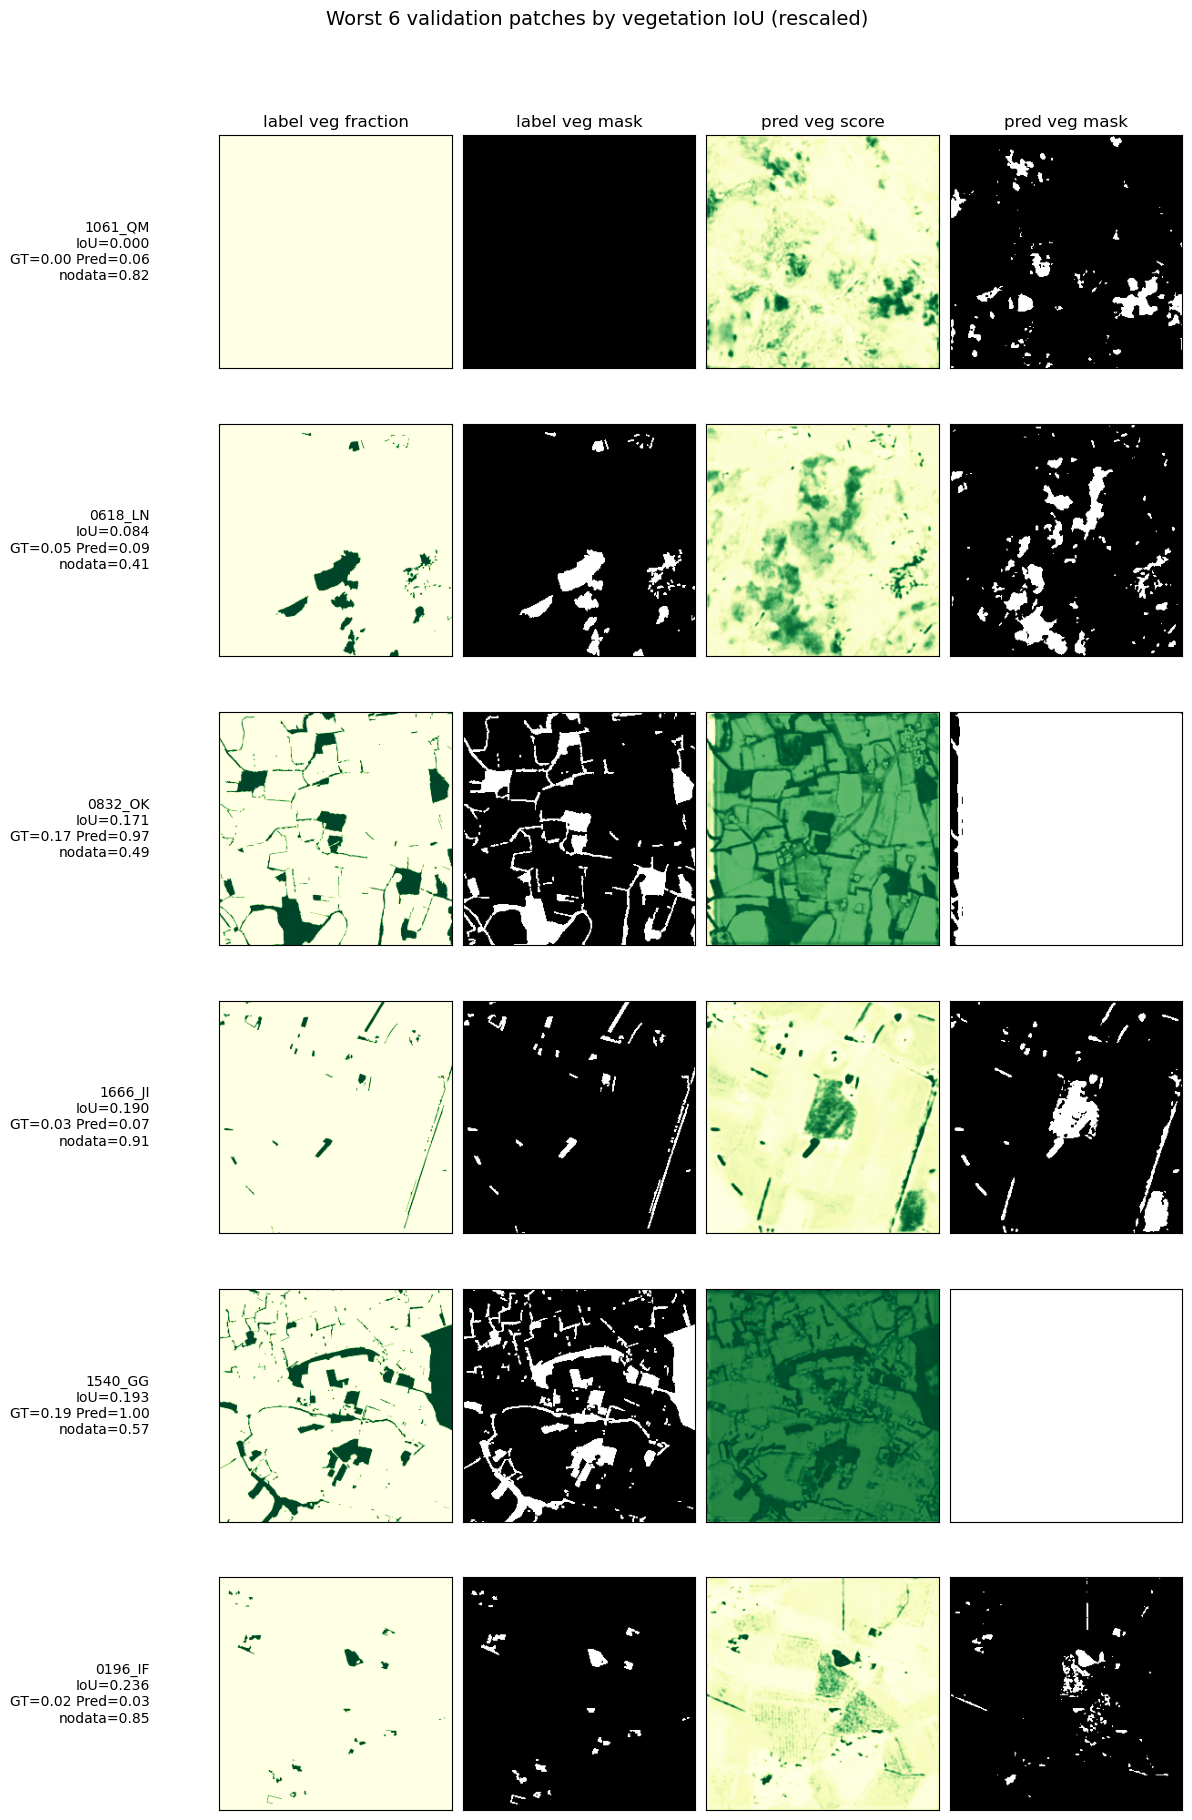

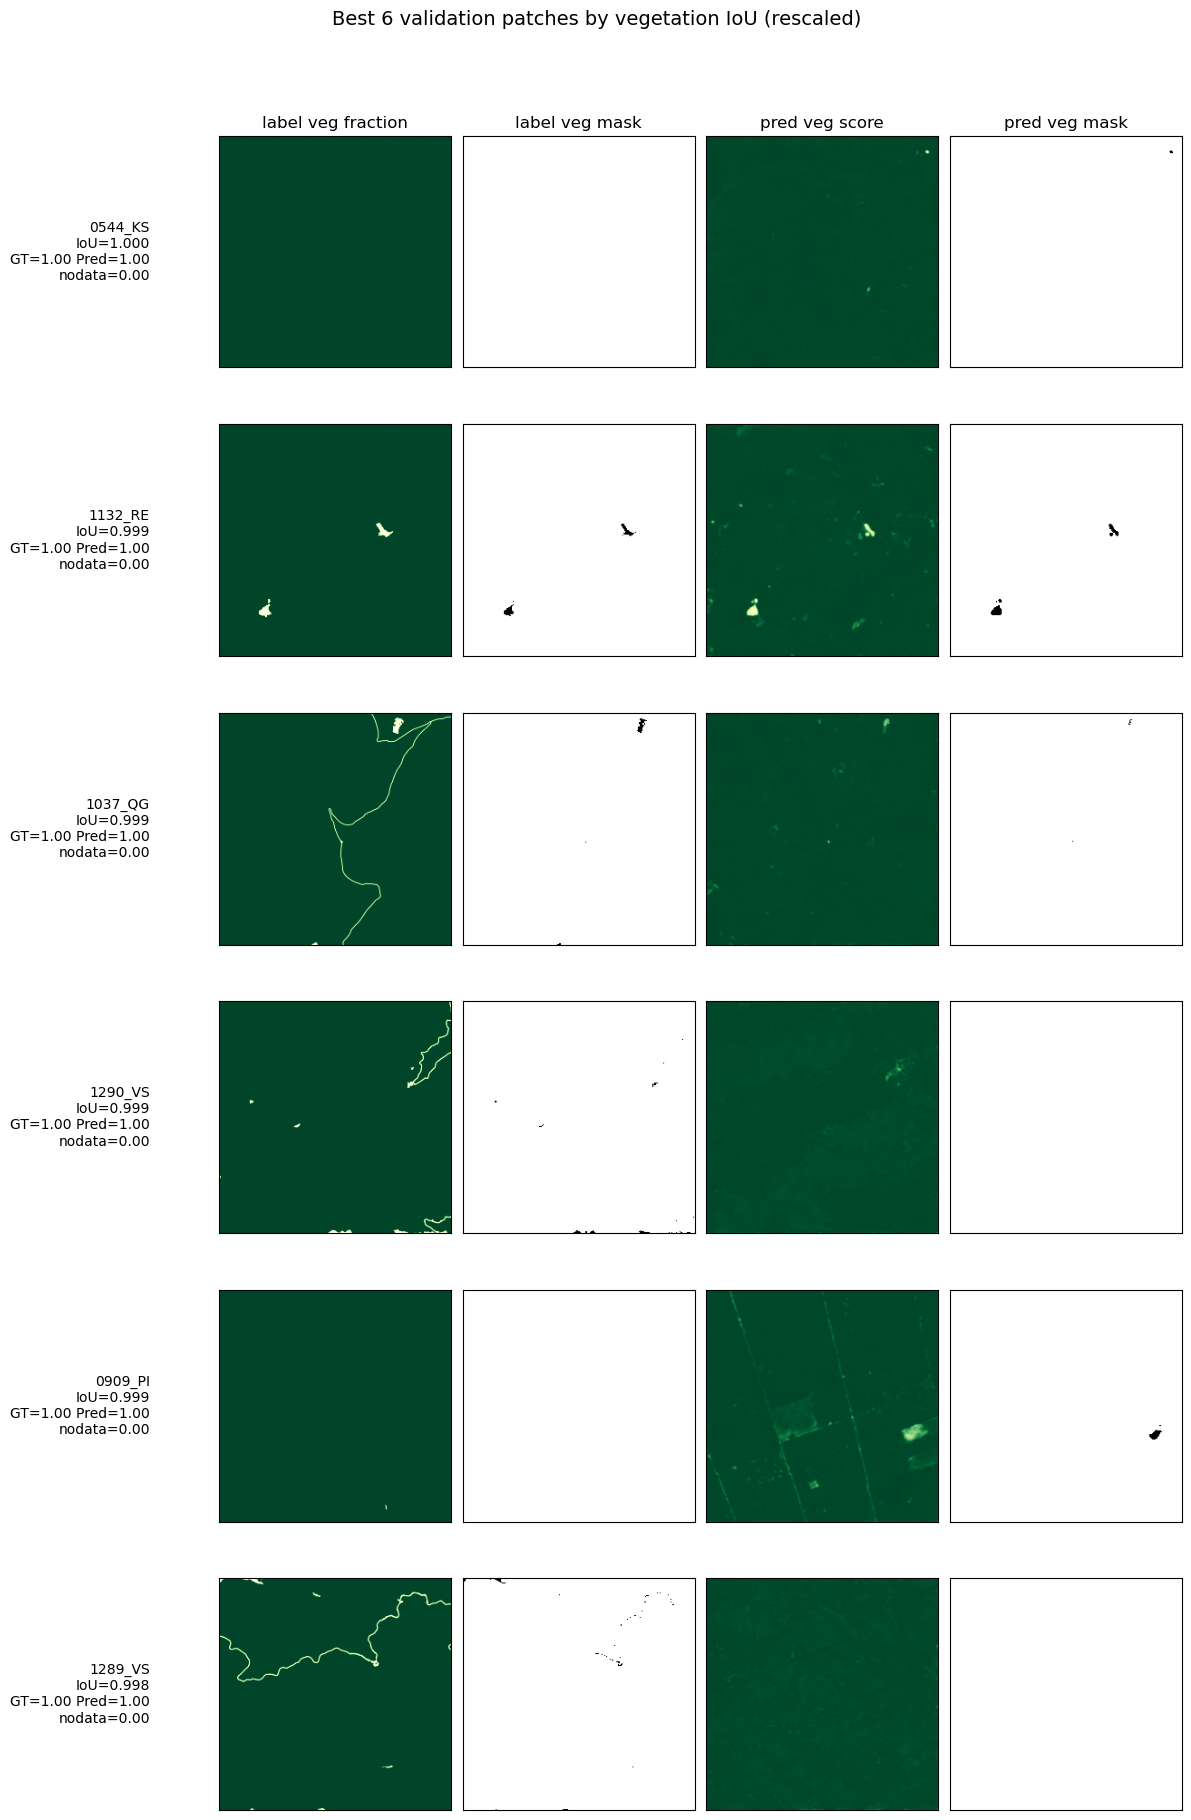

In [8]:
def show_gallery(core_ids, title):
    fig, axes = plt.subplots(len(core_ids), 4, figsize=(12, 3 * len(core_ids)))
    if len(core_ids) == 1:
        axes = np.array([axes])

    for row_idx, cid in enumerate(core_ids):
        arr = arrays[cid]
        meta = next(row for row in rows if row["core_id"] == cid)
        panels = [
            (arr["label_veg_frac"], "label veg fraction", "YlGn"),
            (arr["label_veg_mask"], "label veg mask", "gray"),
            (arr["pred_cal_veg_score"], "pred veg score", "YlGn"),
            (arr["pred_cal_veg_mask"], "pred veg mask", "gray"),
        ]
        for col_idx, (img, subtitle, cmap) in enumerate(panels):
            ax = axes[row_idx, col_idx]
            im = ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
            ax.set_xticks([])
            ax.set_yticks([])
            if row_idx == 0:
                ax.set_title(subtitle)
            if col_idx == 0:
                ax.set_ylabel(
                    f"{cid}\nIoU={meta['cal_veg_iou']:.3f}\n"
                    f"GT={meta['label_veg_pos_rate']:.2f} Pred={meta['pred_cal_veg_pos_rate']:.2f}\n"
                    f"nodata={meta['nodata_frac']:.2f}",
                    rotation=0,
                    ha="right",
                    va="center",
                    labelpad=50,
                )
    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

show_gallery(worst_ids, "Worst 6 validation patches by vegetation IoU (rescaled)")
show_gallery(best_ids, "Best 6 validation patches by vegetation IoU (rescaled)")


## Polarization probe

Hypothesis from discussion: patches with low IoU are not missing information — the continuous scores
just cluster around 0.5, so the global threshold 0.54 cuts through the fattest part of the distribution
and the binary mask becomes unstable.

If the hypothesis holds we expect:
- worst-6 patches have a much larger fraction of pixels in the ambiguous band `[0.3, 0.7]` than best-6
- the ambiguous fraction correlates negatively with IoU across the full validation set
- a per-patch Otsu threshold (picked from each patch's own score histogram) beats the global 0.54

If the hypothesis fails we expect:
- worst-6 patches already have most mass near 0 or 1 — the model is confident and just wrong
- Otsu per-patch would not help (nothing new to separate)

n_patches = 405
Ambiguous [0.3, 0.7] fraction: mean=0.086  median=0.079  max=0.585
Near-zero (<0.1) fraction:     mean=0.303
Near-one  (>0.9) fraction:     mean=0.372
corr(ambiguous_frac, IoU)      = -0.319
corr(near_zero, IoU)           = -0.669
corr(near_one,  IoU)           = +0.789

Worst-6 polarization:
  1061_QM  amb=0.133  near0=0.438  near1=0.007  IoU=0.000
  0618_LN  amb=0.187  near0=0.438  near1=0.003  IoU=0.084
  0832_OK  amb=0.585  near0=0.005  near1=0.157  IoU=0.171
  1666_JI  amb=0.054  near0=0.449  near1=0.016  IoU=0.190
  1540_GG  amb=0.006  near0=0.000  near1=0.259  IoU=0.193
  0196_IF  amb=0.064  near0=0.525  near1=0.008  IoU=0.236
Best-6 polarization:
  0544_KS  amb=0.000  near0=0.000  near1=0.999  IoU=1.000
  1132_RE  amb=0.002  near0=0.000  near1=0.990  IoU=0.999
  1037_QG  amb=0.000  near0=0.000  near1=0.997  IoU=0.999
  1290_VS  amb=0.000  near0=0.000  near1=0.998  IoU=0.999
  0909_PI  amb=0.004  near0=0.000  near1=0.984  IoU=0.999
  1289_VS  amb=0.000  near0=0.0

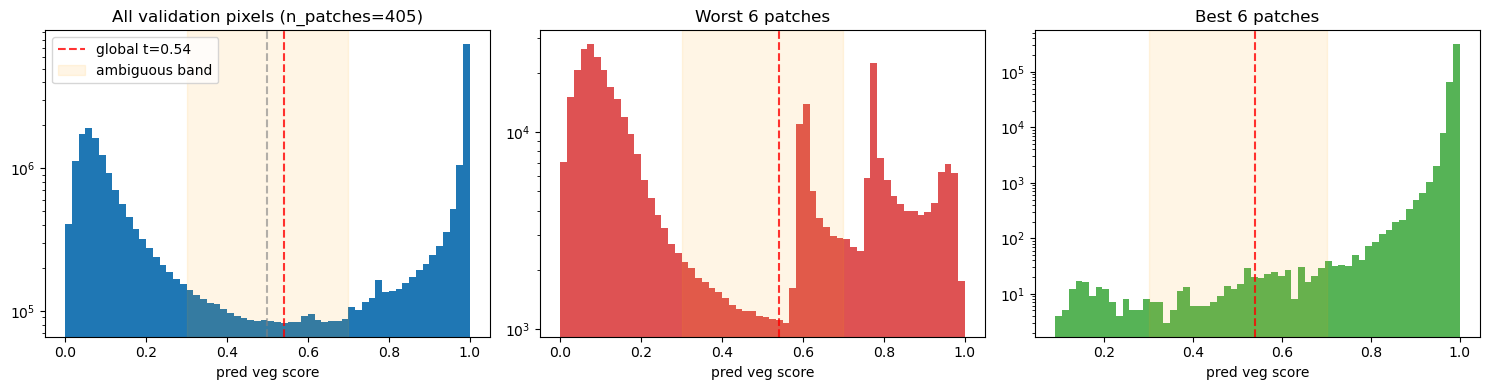

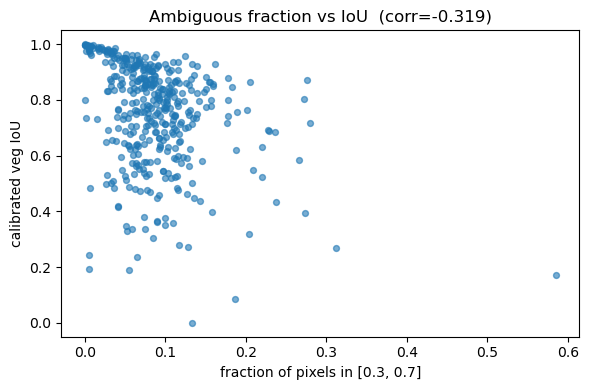

In [9]:
def polarization_stats(scores):
    total = scores.size
    return {
        "near_zero": float((scores < 0.1).sum() / total),
        "near_one": float((scores > 0.9).sum() / total),
        "ambiguous_0.3_0.7": float(((scores >= 0.3) & (scores <= 0.7)).sum() / total),
        "mean": float(scores.mean()),
        "std": float(scores.std()),
    }

polar_rows = []
for row in rows:
    arr = arrays[row["core_id"]]
    stats = polarization_stats(arr["pred_raw_veg_score"])
    stats["core_id"] = row["core_id"]
    stats["cal_veg_iou"] = row["cal_veg_iou"]
    polar_rows.append(stats)

amb = np.array([r["ambiguous_0.3_0.7"] for r in polar_rows])
iou = np.array([r["cal_veg_iou"] for r in polar_rows])
near0 = np.array([r["near_zero"] for r in polar_rows])
near1 = np.array([r["near_one"] for r in polar_rows])

print(f"n_patches = {len(polar_rows)}")
print(f"Ambiguous [0.3, 0.7] fraction: mean={amb.mean():.3f}  median={np.median(amb):.3f}  max={amb.max():.3f}")
print(f"Near-zero (<0.1) fraction:     mean={near0.mean():.3f}")
print(f"Near-one  (>0.9) fraction:     mean={near1.mean():.3f}")
print(f"corr(ambiguous_frac, IoU)      = {np.corrcoef(amb, iou)[0, 1]:+.3f}")
print(f"corr(near_zero, IoU)           = {np.corrcoef(near0, iou)[0, 1]:+.3f}")
print(f"corr(near_one,  IoU)           = {np.corrcoef(near1, iou)[0, 1]:+.3f}")

worst_lookup = {r["core_id"]: r for r in polar_rows}
print("\nWorst-6 polarization:")
for cid in worst_ids:
    r = worst_lookup[cid]
    print(f"  {cid}  amb={r['ambiguous_0.3_0.7']:.3f}  near0={r['near_zero']:.3f}  near1={r['near_one']:.3f}  IoU={r['cal_veg_iou']:.3f}")
print("Best-6 polarization:")
for cid in best_ids:
    r = worst_lookup[cid]
    print(f"  {cid}  amb={r['ambiguous_0.3_0.7']:.3f}  near0={r['near_zero']:.3f}  near1={r['near_one']:.3f}  IoU={r['cal_veg_iou']:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

all_scores = np.concatenate([arrays[r["core_id"]]["pred_raw_veg_score"].ravel() for r in rows])
axes[0].hist(all_scores, bins=60, log=True)
axes[0].axvline(0.5, color="gray", ls="--", alpha=0.6)
axes[0].axvline(0.54, color="red", ls="--", alpha=0.8, label="global t=0.54")
axes[0].axvspan(0.3, 0.7, color="orange", alpha=0.1, label="ambiguous band")
axes[0].set_title(f"All validation pixels (n_patches={len(rows)})")
axes[0].set_xlabel("pred veg score")
axes[0].legend()

worst_scores = np.concatenate([arrays[cid]["pred_raw_veg_score"].ravel() for cid in worst_ids])
axes[1].hist(worst_scores, bins=60, log=True, color="C3", alpha=0.8)
axes[1].axvline(0.54, color="red", ls="--", alpha=0.8)
axes[1].axvspan(0.3, 0.7, color="orange", alpha=0.1)
axes[1].set_title("Worst 6 patches")
axes[1].set_xlabel("pred veg score")

best_scores = np.concatenate([arrays[cid]["pred_raw_veg_score"].ravel() for cid in best_ids])
axes[2].hist(best_scores, bins=60, log=True, color="C2", alpha=0.8)
axes[2].axvline(0.54, color="red", ls="--", alpha=0.8)
axes[2].axvspan(0.3, 0.7, color="orange", alpha=0.1)
axes[2].set_title("Best 6 patches")
axes[2].set_xlabel("pred veg score")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(amb, iou, s=18, alpha=0.6)
ax.set_xlabel("fraction of pixels in [0.3, 0.7]")
ax.set_ylabel("calibrated veg IoU")
ax.set_title(f"Ambiguous fraction vs IoU  (corr={np.corrcoef(amb, iou)[0, 1]:+.3f})")
plt.tight_layout()
plt.show()

## Per-patch adaptive threshold (Otsu) vs global 0.54

Pick a threshold per patch by Otsu's method on that patch's own pred histogram.
Compare IoU against the global 0.54 threshold.

Three signals to read:
- **mean IoU delta** — positive means per-patch thresholding wins overall
- **Otsu threshold distribution** — if tightly clustered around 0.54, adaptive thresholding can't add much; if spread out, global is systematically wrong on many patches
- **worst-6 recovery** — the original motivation was to rescue those; check if Otsu actually lifts them

Global t=0.54 mean IoU:   0.7533
Per-patch Otsu mean IoU:  0.7539
Mean delta:               +0.0006
Median delta:             -0.0001
Patches improved (>+0.01):  36  /  405
Patches degraded (<-0.01):  43  /  405
Patches unchanged (±0.01): 326  /  405

Otsu threshold percentiles (5/25/50/75/95):
  [0.432 0.49  0.529 0.588 0.75 ]

Worst-6 under Otsu:
  1061_QM  t_otsu=0.334  global_iou=0.000  otsu_iou=0.000  delta=+0.000
  0618_LN  t_otsu=0.334  global_iou=0.084  otsu_iou=0.098  delta=+0.014
  0832_OK  t_otsu=0.740  global_iou=0.171  otsu_iou=0.451  delta=+0.280
  1666_JI  t_otsu=0.420  global_iou=0.190  otsu_iou=0.182  delta=-0.009
  1540_GG  t_otsu=0.857  global_iou=0.193  otsu_iou=0.468  delta=+0.275
  0196_IF  t_otsu=0.322  global_iou=0.236  otsu_iou=0.131  delta=-0.105
Best-6 under Otsu:
  0544_KS  t_otsu=0.752  global_iou=1.000  otsu_iou=1.000  delta=-0.000
  1132_RE  t_otsu=0.635  global_iou=0.999  otsu_iou=0.999  delta=-0.000
  1037_QG  t_otsu=0.881  global_iou=0.999  otsu_iou=0.

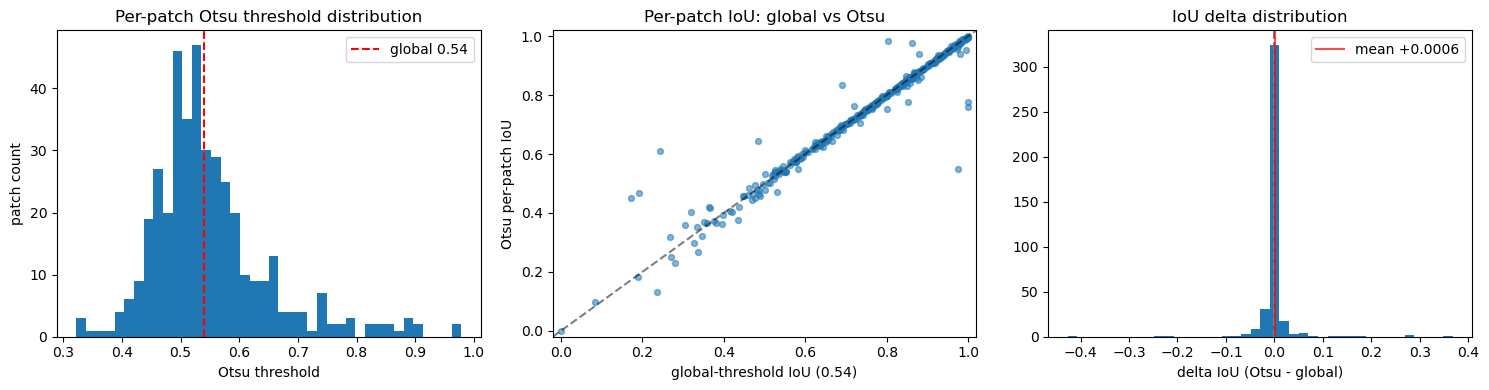

In [10]:
def otsu_threshold(values, bins=256):
    hist, edges = np.histogram(values, bins=bins, range=(0.0, 1.0))
    hist = hist.astype(np.float64)
    total = hist.sum()
    if total <= 0:
        return 0.5
    probs = hist / total
    centers = 0.5 * (edges[:-1] + edges[1:])
    w0 = np.cumsum(probs)
    w1 = 1.0 - w0
    with np.errstate(divide="ignore", invalid="ignore"):
        mu0 = np.cumsum(probs * centers) / np.where(w0 > 1e-12, w0, 1.0)
        mu_total = (probs * centers).sum()
        mu1 = (mu_total - np.cumsum(probs * centers)) / np.where(w1 > 1e-12, w1, 1.0)
    sigma_b2 = w0 * w1 * (mu0 - mu1) ** 2
    sigma_b2 = np.where(np.isfinite(sigma_b2), sigma_b2, -1.0)
    best_idx = int(np.argmax(sigma_b2))
    return float(centers[best_idx])

otsu_rows = []
for row in rows:
    cid = row["core_id"]
    arr = arrays[cid]
    score = arr["pred_raw_veg_score"]
    label_mask = arr["label_veg_mask"].astype(bool)
    t_otsu = otsu_threshold(score)
    otsu_mask = score > t_otsu
    otsu_iou = binary_iou(otsu_mask, label_mask)
    otsu_rows.append({
        "core_id": cid,
        "t_otsu": t_otsu,
        "otsu_iou": otsu_iou,
        "global_iou": row["cal_veg_iou"],
        "delta": otsu_iou - row["cal_veg_iou"],
    })

t_otsu_arr = np.array([r["t_otsu"] for r in otsu_rows])
otsu_iou_arr = np.array([r["otsu_iou"] for r in otsu_rows])
global_iou_arr = np.array([r["global_iou"] for r in otsu_rows])
delta_arr = otsu_iou_arr - global_iou_arr

print(f"Global t=0.54 mean IoU:   {global_iou_arr.mean():.4f}")
print(f"Per-patch Otsu mean IoU:  {otsu_iou_arr.mean():.4f}")
print(f"Mean delta:               {delta_arr.mean():+.4f}")
print(f"Median delta:             {np.median(delta_arr):+.4f}")
print(f"Patches improved (>+0.01): {(delta_arr > 0.01).sum():3d}  /  {len(delta_arr)}")
print(f"Patches degraded (<-0.01): {(delta_arr < -0.01).sum():3d}  /  {len(delta_arr)}")
print(f"Patches unchanged (±0.01): {(np.abs(delta_arr) <= 0.01).sum():3d}  /  {len(delta_arr)}")
print()
print("Otsu threshold percentiles (5/25/50/75/95):")
print(f"  {np.percentile(t_otsu_arr, [5, 25, 50, 75, 95]).round(3)}")

otsu_lookup = {r["core_id"]: r for r in otsu_rows}
print("\nWorst-6 under Otsu:")
for cid in worst_ids:
    r = otsu_lookup[cid]
    print(f"  {cid}  t_otsu={r['t_otsu']:.3f}  global_iou={r['global_iou']:.3f}  otsu_iou={r['otsu_iou']:.3f}  delta={r['delta']:+.3f}")
print("Best-6 under Otsu:")
for cid in best_ids:
    r = otsu_lookup[cid]
    print(f"  {cid}  t_otsu={r['t_otsu']:.3f}  global_iou={r['global_iou']:.3f}  otsu_iou={r['otsu_iou']:.3f}  delta={r['delta']:+.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(t_otsu_arr, bins=40)
axes[0].axvline(0.54, color="red", ls="--", label="global 0.54")
axes[0].set_xlabel("Otsu threshold")
axes[0].set_ylabel("patch count")
axes[0].set_title("Per-patch Otsu threshold distribution")
axes[0].legend()

lims = [min(global_iou_arr.min(), otsu_iou_arr.min()) - 0.02, 1.02]
axes[1].scatter(global_iou_arr, otsu_iou_arr, s=18, alpha=0.55)
axes[1].plot(lims, lims, "k--", alpha=0.5)
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_xlabel("global-threshold IoU (0.54)")
axes[1].set_ylabel("Otsu per-patch IoU")
axes[1].set_title("Per-patch IoU: global vs Otsu")

axes[2].hist(delta_arr, bins=40)
axes[2].axvline(0, color="gray", ls="--")
axes[2].axvline(delta_arr.mean(), color="red", ls="-", alpha=0.7,
                label=f"mean {delta_arr.mean():+.4f}")
axes[2].set_xlabel("delta IoU (Otsu - global)")
axes[2].set_title("IoU delta distribution")
axes[2].legend()

plt.tight_layout()
plt.show()